# General ideas of Grading & scores
We have around 9 projects. Each project scores from 0 to 10 points. The final grade is the average of all projects.
Each project has some problems with different points; you will get scores for each problem:
+	100% points if the results are correct and the explanation of the results is good (if required).
+	80% points if the results are correct but missing the explanation (if required).
+	50% points if the results are incorrect but the logic is right.
+	0% points if the code returns an error or is empty.

Late submissions will lose 50% of the total score of a project. Remember to write comments to explain your code's functionality!

-----------------------------------------------------------------------------------------------------------------------------------------


<!-- # 1. Trapezoide rule & midpoint rule -->

<!-- ![trapezoid.svg](trapezoid.svg) -->

<!-- ![midpoint.png](midpoint.png) -->

<!-- Integration:
$$I = \int_{a}^{b} y(x) dx$$
Trapezoidal rule with uniform distribution:
$$I = \sum_{i=0}^{N-1} \biggl(\dfrac{y(x_i) + y(x_{i+1})}{2}\biggr) \Delta x,$$
Midpoint rule with uniform distribution:
$$I = \sum_{i=0}^{N-1} y\biggl(\dfrac{x_i + x_{i+1}}{2}\biggr) \Delta x,$$
where
$$\Delta x = \dfrac{b-a}{N}.$$ -->

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Exercise 1: Generating random numbers in a range

Using numpy.random (or whatever you like), generate:

*	An integer random number in a range [0,5] (using random.integers)
*	100 float random numbers in a range [0,5] (using random.uniform)
*	A 3x3 matrix of floats random number in a range [0,2]

Try using seed and without seed to see the difference.

In [62]:
print("--- WITHOUT SEED ---")
rng_unseeded = np.random.default_rng()

# endpoint=True ensures the upper bound (5) is included in the possible results
rand_int_unseeded = rng_unseeded.integers(0, 5, endpoint=True)

# Generates an array of 100 floats between 0 and 5
rand_floats_unseeded = rng_unseeded.uniform(0, 5, 100)

# The tuple (3, 3) dictates the shape of the output matrix
rand_matrix_unseeded = rng_unseeded.uniform(0, 2, (3, 3))

print(f"Integer: {rand_int_unseeded}")
# Slicing the array [:3] to only print the first 3 elements
print(f"First 3 floats: {rand_floats_unseeded[:3]}")
print(f"Matrix:\n{rand_matrix_unseeded}\n")


print("--- WITH SEED ---")
# Passing a specific integer (12345) forces the math to start from a predictable, fixed state, so the result is always the same
rng_seeded = np.random.default_rng(12345)

rand_int_seeded = rng_seeded.integers(0, 5, endpoint=True)
rand_floats_seeded = rng_seeded.uniform(0, 5, 100)
rand_matrix_seeded = rng_seeded.uniform(0, 2, (3, 3))

print(f"Integer: {rand_int_seeded}")
print(f"First 3 floats: {rand_floats_seeded[:3]}")
print(f"Matrix:\n{rand_matrix_seeded}\n")

--- WITHOUT SEED ---
Integer: 3
First 3 floats: [2.92329493 3.69711793 0.96430971]
Matrix:
[[0.93738428 0.39613062 1.27396342]
 [0.15752394 1.48032466 0.69799536]
 [1.60201684 0.63861643 0.90314622]]

--- WITH SEED ---
Integer: 4
First 3 floats: [1.5837917  3.98682729 3.38127335]
Matrix:
[[0.48028812 1.56001571 0.40753519]
 [1.10410191 0.73398828 1.01456344]
 [0.66687559 0.56544335 0.5636606 ]]


# Exercise 2: Estimating $\pi$ value using the Monte Carlo method
Hint:
![Monte-Carlo01.webp](Monte-Carlo01.webp)
+	The area of a quarter unit circle is $\pi/4$
+	The area of a unit square is 1
$\Rightarrow \pi = 4*\dfrac{S_{\text{quarter circle}}}{S_{\text{square}}} \approx 4*\dfrac{\text{points in circle}}{\text{total points in square}}$

Step:
+	Generate a point (x,y) using 2 random numbers in a range [0,1]
+	Check if the point is inside the circle using the condition $x^2+y^2 <= 1 $
+	Repeat this procedure for many points and compute the ratio.
+	Verify the result by comparing |result - $\pi$|


In [63]:
# CONSTANTS
total_points = 10000000
points_inside_circle = 0
rng_unseeded = np.random.default_rng()

# CALCULATING NUMBER OF POINTS THAT FALL IN THE CIRCLE QUARTER
for i in range(total_points):
    x, y = rng_unseeded.uniform(0, 1, 2)
    if x**2 + y**2 <= 1:
        points_inside_circle += 1

# RESULT
pi_estimate = (points_inside_circle / total_points) * 4
print(f"Estimated value of π: {pi_estimate}")

# VERIFICATION
verify = np.abs(pi_estimate - np.pi)
print(f"Difference between estimated π and actual π: {verify}")

Estimated value of π: 3.1418292
Difference between estimated π and actual π: 0.00023654641020698364


# Exercise 3: Monte Carlo Integration

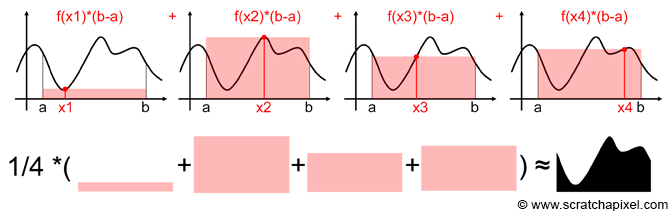

Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$ 

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral? 
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

In [64]:
def MC_1dim(lower_bound, upper_bound, func, n_points):
    """
    Computes the 1D integral using the Monte Carlo method.
    Returns the estimated integral and the standard error.
    """
    # Generate "n_points" random points between lower_bound and upper_bound
    x = np.random.uniform(lower_bound, upper_bound, n_points)

    # Evaluate the function at these points
    y = func(x)

    # Calculate I(x_i)
    I_vals = (upper_bound - lower_bound) * y

    # Mean estimate (I_bar)
    I_bar = np.mean(I_vals)

    # Sample standard deviation (ddof=1 for N-1 in the denominator)
    sigma_I = np.std(I_vals, ddof=1)

    # Standard error
    sigma_I_bar = sigma_I / np.sqrt(n_points)

    return I_bar, sigma_I_bar

# Compute the Integral and Verify Absolute Error

In [65]:
def f(x):
    return np.sin(x)

a = 0
b = np.pi
exact_value = 2.0
n_test = 100000

I_est, std_err = MC_1dim(a, b, f, n_test)
abs_err = np.abs(I_est - exact_value)

print(f"--- Single Run (N = {n_test}) ---")
print(f"Estimated Integral:  {I_est:.6f} +/- {std_err:.6f}")
print(f"Absolute Error:      {abs_err:.6f}\n")

--- Single Run (N = 100000) ---
Estimated Integral:  2.000056 +/- 0.003053
Absolute Error:      0.000056


# Analyze Convergence & Compare with Trapezoid Method

In [66]:
# Generate a range of N values (logarithmically spaced)
N_vals = np.logspace(2, 6, 20).astype(int)

mc_abs_errors = []
mc_std_errors = []
trap_abs_errors = []

for N in N_vals:
    # Monte Carlo method
    I_mc, err_mc = MC_1dim(a, b, f, N)
    mc_abs_errors.append(np.abs(I_mc - exact_value))
    mc_std_errors.append(err_mc)

    # Trapezoidal method
    x_trap = np.linspace(a, b, N)
    y_trap = f(x_trap)
    I_trap = np.trapz(y_trap, x_trap)
    trap_abs_errors.append(np.abs(I_trap - exact_value))

# Convert lists to numpy arrays for calculation
mc_abs_errors = np.array(mc_abs_errors)
mc_std_errors = np.array(mc_std_errors)
trap_abs_errors = np.array(trap_abs_errors)

# Results

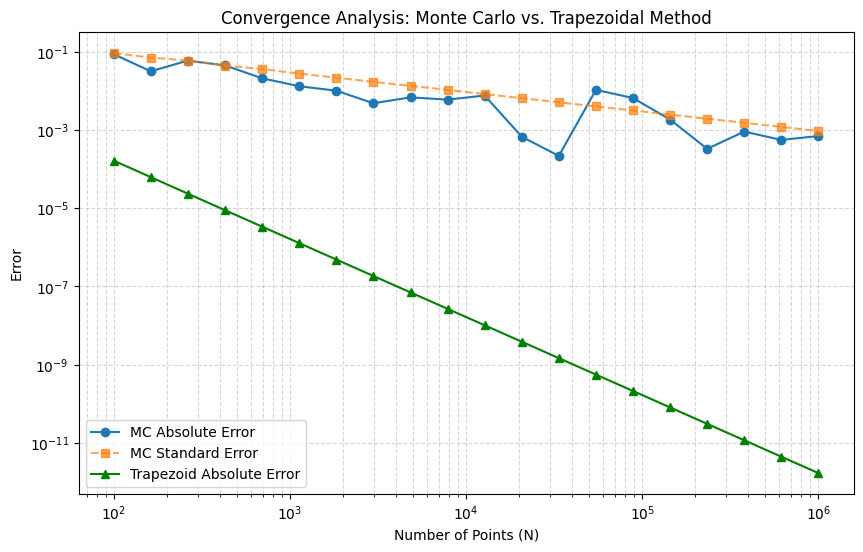

In [67]:
plt.figure(figsize=(10, 6))

# Plot Monte Carlo Errors
plt.loglog(N_vals, mc_abs_errors, 'o-', label='MC Absolute Error')
plt.loglog(N_vals, mc_std_errors, 's--', label='MC Standard Error', alpha=0.7)

# Plot Trapezoid Errors
plt.loglog(N_vals, trap_abs_errors, '^-', label='Trapezoid Absolute Error', color='green')

plt.xlabel('Number of Points (N)')
plt.ylabel('Error')
plt.title('Convergence Analysis: Monte Carlo vs. Trapezoidal Method')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Discussion: How do these errors behave as the number of points increases?
Both the standard error and absolute error decrease as the number of points (N) increases, creating a downward linear trend on a log-log plot.

The standard error decreases smoothly, while the absolute error shows random statistical fluctuations (noise) around that same downward path.

# Which method converges faster for this one-dimensional integral?
On the log-log scale, the trapezoidal error line is much steeper, it converges much faster.

# Compute Scaling factor Alpha

In [68]:
# Pick two indices to compute the slope
idx1, idx2 = 5, 15
x1, x2 = N_vals[idx1], N_vals[idx2]

# Monte Carlo Alpha
y1_mc, y2_mc = mc_std_errors[idx1], mc_std_errors[idx2]
alpha_mc = - (np.log(y2_mc) - np.log(y1_mc)) / (np.log(x2) - np.log(x1))

# Trapezoid Alpha
y1_trap, y2_trap = trap_abs_errors[idx1], trap_abs_errors[idx2]
alpha_trap = - (np.log(y2_trap) - np.log(y1_trap)) / (np.log(x2) - np.log(x1))

print("--- Convergence Scaling (Alpha) ---")
print(f"Points used for slope calculation: N1 = {x1}, N2 = {x2}")
print(f"Calculated Monte Carlo alpha: {alpha_mc:.3f} (Expected: ~0.5)")
print(f"Calculated Trapezoid alpha:   {alpha_trap:.3f} (Expected: ~2.0)")

--- Convergence Scaling (Alpha) ---
Points used for slope calculation: N1 = 1128, N2 = 143844
Calculated Monte Carlo alpha: 0.499 (Expected: ~0.5)
Calculated Trapezoid alpha:   2.000 (Expected: ~2.0)


# Exercise 4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$ 

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ? 

In [69]:
def MC_ndim(lower, upper, func, n_dims, n_points):
    """
    Computes the n-dimensional integral using the Monte Carlo method.
    """
    # Generate random points of shape (n_points, n_dims)
    x = np.random.uniform(lower, upper, size=(n_points, n_dims))

    # Evaluate the function at all points
    f_vals = func(x)

    # Calculate the volume factor: (b - a)^n
    vol = (upper - lower) ** n_dims

    # Mean of the function values
    f_mean = np.mean(f_vals)

    # Sample standard deviation of the function values
    f_std = np.std(f_vals, ddof=1)

    # Estimated integral
    I_bar = vol * f_mean

    # Standard error
    sigma_I_bar = (vol / np.sqrt(n_points)) * f_std

    return I_bar, sigma_I_bar

# Test with the 2D Integral

In [70]:
def f_sin(x):
    return np.prod(np.sin(x), axis=1)

lower_bound = 0
upper_bound = np.pi
n_points_2d = 100000

I_est_2d, std_err_2d = MC_ndim(lower_bound, upper_bound, f_sin, 2, n_points_2d)
exact_2d = 2 ** 2

print("--- 2D Integral Test ---")
print(f"Estimated Integral: {I_est_2d:.6f} +/- {std_err_2d:.6f}")
print(f"Exact Value:        {exact_2d}")
print(f"Absolute Error:     {np.abs(I_est_2d - exact_2d):.6f}\n")

--- 2D Integral Test ---
Estimated Integral: 3.997021 +/- 0.009146
Exact Value:        4
Absolute Error:     0.002979


# Higher Dimensions (5, 7, 9) and Convergence Plot

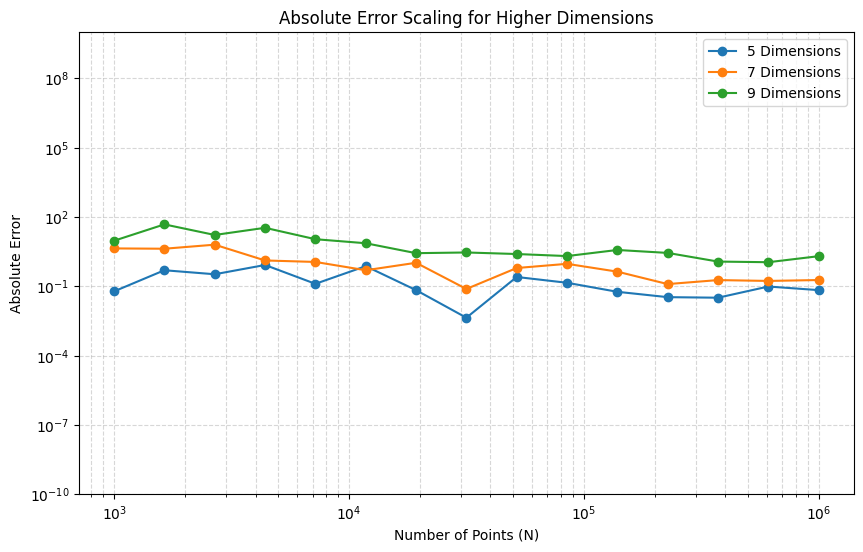

In [71]:
dims_to_test = [5, 7, 9]
N_vals = np.logspace(3, 6, 15).astype(int)

plt.figure(figsize=(10, 6))

for d in dims_to_test:
    abs_errors = []
    exact_val = 2 ** d

    for N in N_vals:
        I_est, _ = MC_ndim(lower_bound, upper_bound, f_sin, d, N)
        error = np.abs(I_est - exact_val)
        abs_errors.append(error)

    plt.loglog(N_vals, abs_errors, marker='o', label=f'{d} Dimensions')

plt.xlabel('Number of Points (N)')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Scaling for Higher Dimensions')
plt.ylim(1e-10, 1e10)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# Does the slope of error line change when we increase the dimension?
No, the slope of the error line remains constant across all dimensions. While the number of points increases significantly, the downward slope always remains approximately -0.5.

# What is your conclusion?
Regardless of whether we are computing a 2D integral or a 9D integral, the standard error always scales similarly.